In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

dev = pd.read_csv("/content/drive/MyDrive/data/FSD50K.metadata/collection/collection_dev.csv")
eval = pd.read_csv("/content/drive/MyDrive/data/FSD50K.metadata/collection/collection_eval.csv")

print("Train samples:", len(dev))
print("Test samples:", len(eval))

dev.head()

Train samples: 40966
Test samples: 10231


,fname,labels,mids
0,64760,Electric_guitar,/m/02sgy
1,16399,Electric_guitar,/m/02sgy
2,16401,Electric_guitar,/m/02sgy
3,16402,Electric_guitar,/m/02sgy
4,16404,Electric_guitar,/m/02sgy


In [ ]:
# Basic dataset overview

print("DEV SHAPE:", dev.shape)
print("EVAL SHAPE:", eval.shape)
print("\nDEV COLUMNS:", list(dev.columns))
print("\nFirst 5 rows:")
display(dev.head())

DEV SHAPE: (40966, 3)
EVAL SHAPE: (10231, 3)

DEV COLUMNS: ['fname', 'labels', 'mids']

First 5 rows:


,fname,labels,mids
0,64760,Electric_guitar,/m/02sgy
1,16399,Electric_guitar,/m/02sgy
2,16401,Electric_guitar,/m/02sgy
3,16402,Electric_guitar,/m/02sgy
4,16404,Electric_guitar,/m/02sgy


In [8]:
# Classes in split

labels_split = dev["labels"].dropna().astype(str).str.split(",")

all_labels = [label.strip() for sublist in labels_split for label in sublist]

label_counts = Counter(all_labels)

print("\nTotal label assignments in dev:", len(all_labels))
print("Unique classes in dev:", len(label_counts))

# Top 20 most frequent classes
top_classes = pd.DataFrame(label_counts.most_common(20), columns=["label", "count"])

print("\nTop 20 most frequent classes:")
display(top_classes)


Total label assignments in dev: 47175
Unique classes in dev: 354

Top 20 most frequent classes:


,label,count
0,Laughter,743
1,Snare_drum,693
2,Cello,643
3,Clarinet,591
4,Saxophone,582
5,Trumpet,581
6,Piano,570
7,Violin_and_fiddle,547
8,Acoustic_guitar,538
9,Fart,533


In [9]:
# Multilabel analysis

dev["num_labels"] = dev["labels"].apply(lambda x: len(str(x).split(",")))

print("\nLabels per clip statistics:")
display(dev["num_labels"].describe())

print("\nLabels per clip counts:")
display(dev["num_labels"].value_counts().sort_index())



Labels per clip statistics:


,num_labels
count,40966.000000
mean,1.154250
std,0.428119
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,8.000000



Labels per clip counts:


,count
num_labels,
1,35568
2,4605
3,689
4,85
5,17
7,1
8,1


In [10]:
# Rare classes

rare_classes = [c for c, n in label_counts.items() if n < 20]
print("\nNumber of rare classes (<20 samples):", len(rare_classes))
print("First 20 rare classes:", rare_classes[:20])


Number of rare classes (<20 samples): 73
First 20 rare classes: ['Toot', 'Skidding', 'Fire_engine_and_fire_truck_(siren)', 'Power_windows_and_electric_windows', 'Emergency_vehicle', 'Train_horn', 'Steam', 'Caw', 'Children_playing', 'Music', 'Rodents_and_rats_and_mice', 'Hubbub_and_speech_noise_and_speech_babble', 'Narration_and_monologue', 'Foghorn', 'Steam_whistle', 'Train_whistle', 'Air_horn_and_truck_horn', 'Car_alarm', 'Fire_alarm', 'Rustling_leaves']


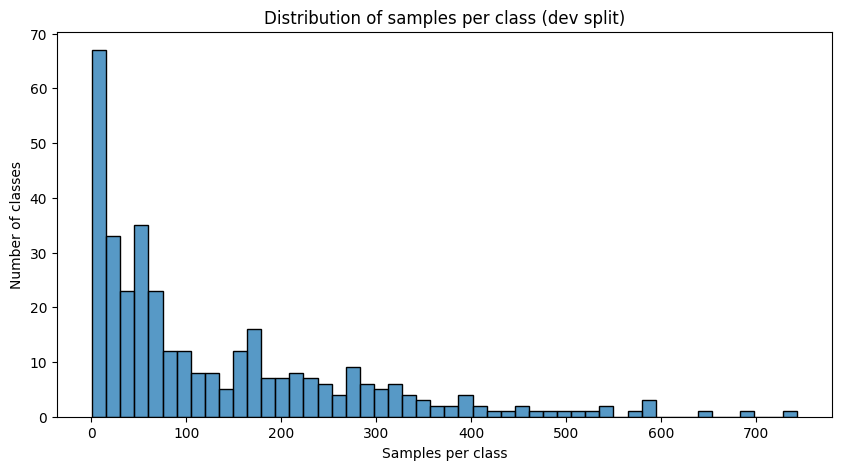

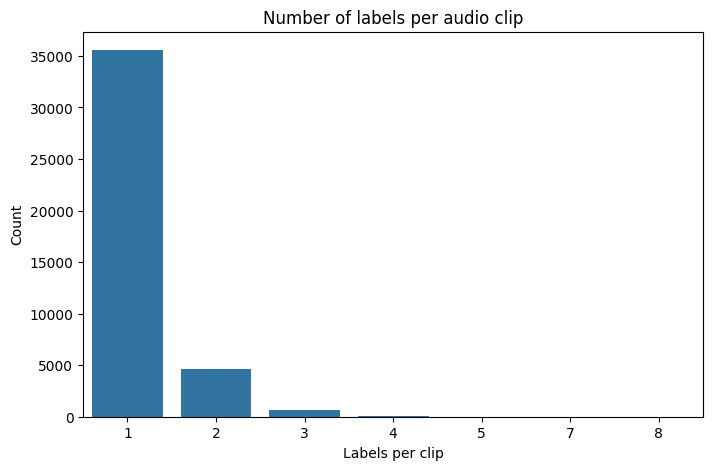

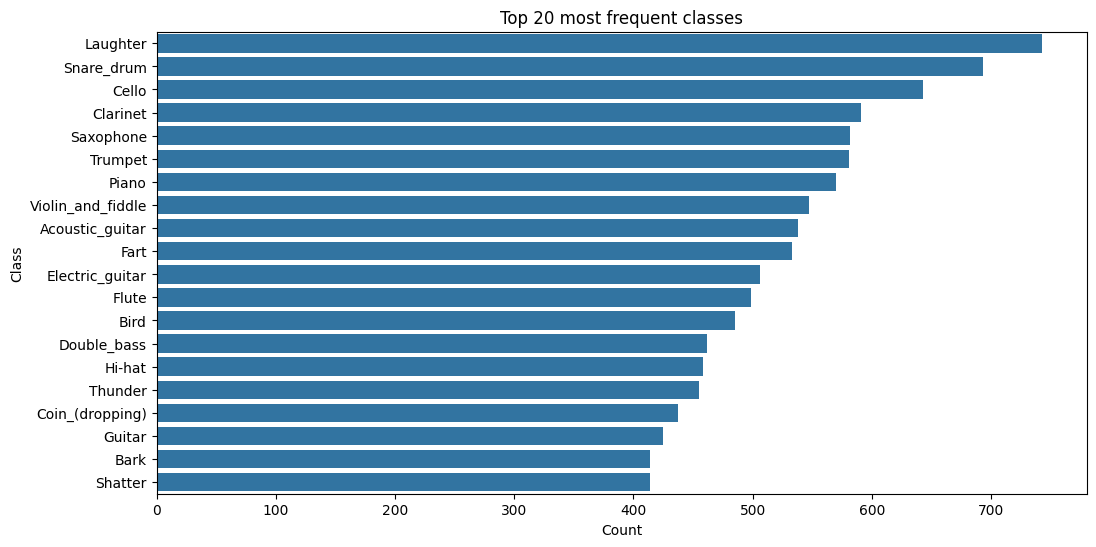

In [11]:
# Plots
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(list(label_counts.values()), bins=50)
plt.title("Distribution of samples per class (dev split)")
plt.xlabel("Samples per class")
plt.ylabel("Number of classes")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x=dev["num_labels"])
plt.title("Number of labels per audio clip")
plt.xlabel("Labels per clip")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_classes, x="count", y="label")
plt.title("Top 20 most frequent classes")
plt.xlabel("Count")
plt.ylabel("Class")
plt.show()

In [12]:
#Summary
print("\n--- QUICK SUMMARY ---")
print(f"The dev split contains {len(dev)} audio clips.")
print(f"The eval split contains {len(eval)} audio clips.")
print(f"There are {len(label_counts)} unique sound classes in the dev split.")
print("The dataset is multi-label, since each audio clip may contain more than one label.")
print("The class distribution is imbalanced, with some classes having many more samples than others.")
print(f"There are {len(rare_classes)} classes with fewer than 20 samples in the dev split.")


--- QUICK SUMMARY ---
The dev split contains 40966 audio clips.
The eval split contains 10231 audio clips.
There are 354 unique sound classes in the dev split.
The dataset is multi-label, since each audio clip may contain more than one label.
The class distribution is imbalanced, with some classes having many more samples than others.
There are 73 classes with fewer than 20 samples in the dev split.
